# Cross integration

**Cross integration** has several batches in which **all** modalities are present; the task is removing batch effects while keeping biological structure. Spatial registration (PASTE, PASTE2, SPIRAL, GPSA) also lives under `cross` - see the note at the end.

**Reference dataset:** `D52` (23,478 cells). The stored results
shipped with these notebooks were produced on it, so every table here
reproduces.

## 1. Install

`pip install multibench-sc` is the whole install: the 1.3 MB wheel ships the
method registry, the stored result tables, the env lockfiles and the reference
metadata. The package alone runs this section, section 3 (`scan`) and sections
4-5. Running methods (section 2, and `run_all` in section 3) additionally
needs their conda environments on a **Linux** host. The flag cell decides:
with `INSTALL_ENVS = False` (the default) **Run all** is safe anywhere -
nothing is downloaded, and a run cell on a host without the environments
prints one line and falls back to the package's stored sweep; set it `True`
on Colab or a Linux machine to download the environments in section 2 and
run the methods for real.

In [1]:
import importlib.util, sys
if importlib.util.find_spec("multibench") is None:
    !{sys.executable} -m pip -q install "multibench-sc>=0.3"   # registry, stored tables, env lockfiles and references ship in the wheel - no clone needed
    if importlib.util.find_spec("multibench") is None:        # PyPI behind the docs? take the same code straight from GitHub
        !{sys.executable} -m pip -q install "git+https://github.com/DSichang/scMultiBench.git"
else:
    print("multibench already installed")

multibench already installed


In [2]:
# "Run all" switch. False (the default): nothing is downloaded and no method executes -
# every section runs on any machine, and the run cells fall back to the package's stored sweep.
# True: on Colab / Linux, provision conda and download the packed environments for the
# methods this notebook runs (2 envs, at least 3.0 GB to download), then run them here for real.
INSTALL_ENVS = False

In [3]:
%matplotlib inline
import warnings
from pathlib import Path
import anndata
import pandas as pd
for _w in (FutureWarning, DeprecationWarning, pd.errors.PerformanceWarning,
           anndata.ImplicitModificationWarning):   # library noise only - multibench's own warnings stay visible
    warnings.filterwarnings("ignore", category=_w)
pd.set_option("display.max_colwidth", None)   # never truncate a `reason`
pd.set_option("display.max_columns", None)    # never hide a metric column
pd.set_option("display.width", 200)
import multibench as mtb

DATASET  = "D52"
CATEGORY = "cross"
mtb.data.fetch('D52')   # reference data (179 MB) -> mtb.config.DEFAULT.data_path; no-op when present
print("multibench", mtb.__version__)

multibench 0.3.0


## 2. Run the analysis

### Environments - only if you will run methods in this session

Linux + conda; 2 envs, at least 3.0 GB to download (2 of 2 archives measured); `multibench env plan --methods StabMap,UINMF,sciPENN` prints the per-env sizes. Both cells below do
nothing unless `INSTALL_ENVS = True`. On Colab the first then provisions
conda and restarts the kernel once: afterwards re-run section 1 (the flag
included), then continue here. Without the environments, section 3's `scan`
and sections 4-5 work as they are.

In [4]:
# Colab ships without conda; with INSTALL_ENVS = True this provisions it (the kernel restarts ONCE).
# On a machine that already has conda, this cell does nothing.
import importlib.util, shutil

def _has(mod):
    try:
        return importlib.util.find_spec(mod) is not None
    except ModuleNotFoundError:
        return False

if not INSTALL_ENVS:
    print("INSTALL_ENVS is False - conda is not provisioned and nothing is downloaded")
elif shutil.which("conda") or shutil.which("mamba"):
    print("conda available - nothing to do")
elif _has("google.colab"):
    !pip -q install condacolab
    import condacolab
    condacolab.install()   # restarts the kernel; afterwards, re-run section 1 (INSTALL_ENVS = True again) and continue here
else:
    print("no conda found - install it first (mamba recommended); see the installation guide")

INSTALL_ENVS is False - conda is not provisioned and nothing is downloaded


Now the environments for the methods this tutorial runs
(StabMap, UINMF, sciPENN). `--packed` downloads a prebuilt archive instead
of solving one from scratch, and `env install` skips anything already
present. Other tiers are one flag away: `--category cross`
(10 envs, at least 30.7 GB to download (10 of 10 archives measured); `multibench env plan --category cross` prints the per-env sizes), or no flag for the whole benchmark (29 envs;
`multibench env plan` totals them). Method environments are linux-64 conda
envs: on macOS / Windows `env install --run` refuses (`--force` overrides),
which is why the cell checks the platform too.

In [5]:
import sys
if not INSTALL_ENVS:
    print("INSTALL_ENVS is False - no environment is downloaded (sections 3-5 need none)")
elif sys.platform != "linux":
    print("method environments are linux-64 conda envs - skipped on", sys.platform)
else:
    !{sys.executable} -m multibench env install --methods StabMap,UINMF,sciPENN --packed --run

INSTALL_ENVS is False - no environment is downloaded (sections 3-5 need none)


### One call

One call is the whole pipeline: resolve each method's inputs, run it in its own
conda env, load the embeddings, score them with scIB metrics. Here
UINMF, sciPENN, StabMap. StabMap is among the fastest cross methods - `run_sec` in the summary is the measured time on our host. The cell first asks `scan` whether
any of these methods has its environment here; where none does (a laptop,
Colab with the flag off) it prints one line and stands in the same methods from the package's own sweep of `D52`
(`load_results(source="rerun")`, the package's re-execution of every wired
method - the paper's own tables are `source="published"`), so every cell
below still renders.

In [6]:
def stored_sweep(dataset, methods=None):
    """The package's own sweep of `dataset` (`load_results(source="rerun")`) as the object
    `run_all` returns, so `.summary` / `.plot()` work on a host that cannot run the methods."""
    long = mtb.load_results(CATEGORY, dataset=dataset, source="rerun", methods=methods)
    recs = [{"method": m, "status": "STORED", "metrics": g.set_index("metric")["value"].to_dict()}
            for m, g in long.groupby("method")]
    return mtb.BatchResult(recs, dataset, CATEGORY)

check = mtb.scan("D52", CATEGORY, methods=['UINMF', 'sciPENN', 'StabMap'])
if check.env_ok.any():
    res = mtb.run_all("D52", CATEGORY,
                      methods=['UINMF', 'sciPENN', 'StabMap'],
                      out_dir="/tmp/tutorial_cross")
else:
    print("no method environment on this host - the run is skipped; the stored results below cover it")
    res = stored_sweep("D52", ['UINMF', 'sciPENN', 'StabMap'])
res.summary

[run_all] StabMap (cross/D52) ...


[run_all]   -> CHAIN_OK (48.8s) 0.688


[run_all] UINMF (cross/D52) ...


[run_all]   -> CHAIN_OK (53.9s) 0.6905


[run_all] sciPENN (cross/D52) ...


[run_all]   -> CHAIN_OK (49.0s) 0.7418


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,ARI,NMI,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI,label_order_note
0,StabMap,CHAIN_OK,48.8,embedding,"[23478, 50]",0,cty3.csv+cty1.csv+cty2.csv,0.8400,file_of_origin,3,0.6880,0.7760,0.5569,0.5656,0.6811,0.9940,0.9241,0.9313,0.5208,None
1,UINMF,CHAIN_OK,53.9,embedding,"[14764, 30]",0,cty1.csv+cty2.csv,0.9996,file_of_origin,2,0.6905,0.7772,0.5668,0.5553,0.6639,0.9933,0.9353,0.9296,0.8664,None
2,sciPENN,CHAIN_OK,49.0,embedding,"[23478, 512]",0,cty1.csv+cty2.csv+cty3.csv,0.8365,file_of_origin,3,0.7418,0.8017,0.6086,0.6229,0.7396,0.9977,0.8804,0.9361,0.3825,None


`summary` is sorted by method name, whatever order `methods=` listed;
`emb_shape` is the embedding each method produced and `batch_source` says which
batch vector the batch metrics used; a stand-in from the stored sweep says
`STORED` in `status` and leaves the run columns empty. UINMF's cross variant consumes batches 1-2 only (its registry modalities are `rna1+rna2+adt1+adt2`), so its `emb_shape` counts fewer cells than the three-batch methods and its metrics are computed on that subset. The
result object plots itself in the paper's layout:

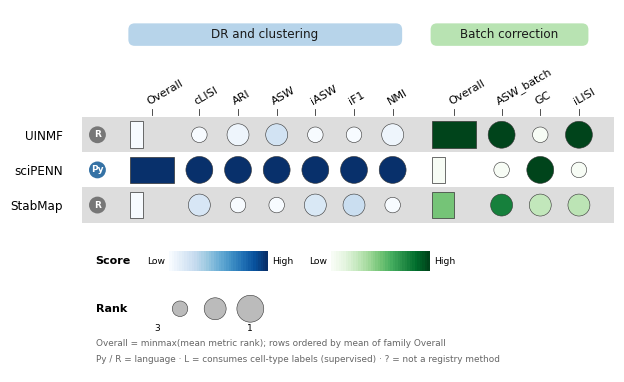

In [7]:
res.plot()

Each circle carries two encodings: its **size is the method's rank** in
that column (largest = rank 1) and its **colour is the metric's value**, min-max
scaled within the column (darker = higher). Columns are grouped by task family -
blues for DR & clustering, greens for batch correction - and each family is led
by an **Overall** rank column, where bar length and colour carry the same two
encodings.

## 3. Your own data

The same three calls - `scan`, `run_all`, `plot` - on a folder the package has
never seen. A dataset is a folder of flat files named by category:

In [8]:
print(mtb.describe_layout(CATEGORY))

Put your files in  <data_path>/<DATASET_NAME>/ , e.g. ./data/MYDATA/
  (dataset = the folder NAME; data_path = the folder that CONTAINS it)

LAYOUT FOR CROSS:
  rna1.h5 rna2.h5 rna3.h5 + adt1.h5 adt2.h5 adt3.h5
  cty1.csv cty2.csv cty3.csv          <- one per batch
  (spatial registration instead takes a directory of .h5ad slices)

  (numbered files live in the SAME flat dir; there is no batch column)

Modality roles and the filenames they resolve to:
    rna              rna.h5      - gene expression
    adt              adt.h5      - surface protein (CITE-seq antibody-derived tags)
    atac             atac.h5     - chromatin accessibility
    atac_gas         atac.h5     - ATAC as GENE-ACTIVITY scores  <-- note: plain atac.h5
    atac_peak        peak.h5     - ATAC as PEAKS                 <-- note: peak.h5, NOT atac.h5
    rna1/rna2/...    rna1.h5, rna2.h5, ... - one file per BATCH (mosaic/cross)
    adt1/adt2/...    adt1.h5, adt2.h5, ... - one file per BATCH (mosaic/cross)
    cty

Each modality file is HDF5 with three datasets:

| dataset | contents | shape |
|---|---|---|
| `matrix/data` | the matrix, **features x cells** | `(n_features, n_cells)` |
| `matrix/features` | one name per feature | `(n_features,)` |
| `matrix/barcodes` | one id per cell | `(n_cells,)` |

That is the **transpose** of the AnnData convention (`AnnData.X` is cells x
genes); the `mtb.io` writers below handle it, and `scan()` rejects a transposed
file at preflight rather than letting a method fail half an hour in. The label
CSV is a **single column** with one header line (typically `x`) and one label
per cell, in the same order as `matrix/barcodes` of the matching modality file.
For ATAC, check which representation a method wants - gene-activity scores or
peaks - because the wrong one runs to completion and returns a plausible but
wrong embedding. The shipped label files, as `evaluate` will read them - the
dict comes back in the benchmark's **cell-stacking order** (`cty`; `cty1, cty2,
...` numerically; `rna_cty` before `atac_cty`), so
`mtb.evaluate(embedding, labels=mtb.labels_for(DATASET), task="all")` scores a
multi-file dataset directly, with each cell's file of origin as its batch (the
default `task="clustering"` computes the clustering family only - batch
metrics need `task="all"` or `"batch"`); a dict you built in any other order
must say so with `label_order=[...]`:

In [9]:
labels = mtb.labels_for(DATASET)            # {stem: path} in cell-stacking order - what the metrics are scored against
print({k: Path(v).name for k, v in labels.items()})
print(*Path(next(iter(labels.values()))).read_text().splitlines()[:4], sep="\n")

{'cty1': 'cty1.csv', 'cty2': 'cty2.csv', 'cty3': 'cty3.csv'}
"x"
"CD4 memory"
"CD8 naive"
"CD4 memory"


Writing that layout from AnnData objects, executed here on a synthetic
example - sparse matrices stream without densifying, and the folder passes the
same file gate `scan` applies to the shipped datasets:

In [10]:
import anndata as ad, numpy as np, tempfile, os
rng = np.random.default_rng(0)
demo = ad.AnnData(X=rng.poisson(1.0, size=(150, 40)).astype(float))            # RNA, cells x genes
demo.var_names = [f"gene{i}" for i in range(40)]
demo.obsm["protein"] = rng.poisson(3.0, size=(150, 12)).astype(float)          # ADT
demo.uns["protein_names"] = [f"CD{i}" for i in range(12)]
demo.obs["celltype"] = rng.choice(["T", "B", "NK"], 150)
demo.obs["batch"]    = rng.choice(["donor1", "donor2", "donor3"], 150)

folder = mtb.io.export_dataset(demo, os.path.join(tempfile.mkdtemp(), "MYCROSS"),
                               rna="X", adt="obsm:protein", labels="obs:celltype",
                               batch="obs:batch")       # batch= -> one numbered file set per batch value
print(sorted(os.listdir(folder)))
sc = mtb.scan("MYCROSS", CATEGORY, data_path=folder.parent)
print(f"{int(sc.files_ok.sum())} of {len(sc)} method variants pass the file gate (the rest are spatial-registration methods)")

['adt1.h5', 'adt2.h5', 'adt3.h5', 'cty1.csv', 'cty2.csv', 'cty3.csv', 'rna1.h5', 'rna2.h5', 'rna3.h5']
8 of 12 method variants pass the file gate (the rest are spatial-registration methods)


Now a real dataset the package has never seen: a 60% cell subsample of
`D52` under a new name, built with ordinary h5py/pandas code so the
per-file rule (matching files keep the same cell index) is visible.

In [11]:
import os, shutil
import h5py
import numpy as np
import pandas as pd

def subsample_dataset(src_dir, dst_dir, frac=0.6, seed=0):
    """Copy a dataset to a new name, keeping a random fraction of the cells.

    Files sharing a cell count get the SAME kept-cell index, so modality files
    and their label CSVs stay aligned - which is exactly the property your own
    export pipeline must preserve. The output is the canonical layout:
    matrix/data as features x cells, plus matrix/features and matrix/barcodes.
    """
    rng = np.random.default_rng(seed)
    os.makedirs(dst_dir, exist_ok=True)
    counts, keep = {}, {}
    for fn in sorted(os.listdir(src_dir)):
        p = os.path.join(src_dir, fn)
        if fn.endswith(".h5"):
            with h5py.File(p) as f:
                if "matrix/data" in f:
                    counts[fn] = f["matrix/data"].shape[1]   # features x cells
        elif fn.endswith(".csv"):
            counts[fn] = len(pd.read_csv(p))
    for n in set(counts.values()):
        k = max(50, int(n * frac))
        keep[n] = np.sort(rng.choice(n, size=k, replace=False))
    for fn, n in counts.items():
        sp, dp = os.path.join(src_dir, fn), os.path.join(dst_dir, fn)
        idx = keep[n]
        if fn.endswith(".csv"):
            pd.read_csv(sp).iloc[idx].to_csv(dp, index=False)
        else:
            with h5py.File(sp) as f, h5py.File(dp, "w") as g:
                grp = g.create_group("matrix")
                grp.create_dataset("data", data=np.asarray(f["matrix/data"])[:, idx])
                if "matrix/features" in f:
                    grp.create_dataset("features", data=np.asarray(f["matrix/features"]))
                if "matrix/barcodes" in f:
                    grp.create_dataset("barcodes", data=np.asarray(f["matrix/barcodes"])[idx])
    return dst_dir

`scan` checks two independent gates per method: `files_ok` - the folder
itself (files present, features x cells orientation, one label per cell) - and
`env_ok` - that method's conda environment exists on this machine. `runnable`
is both; `reason` says which failed and how to fix it. The file gate runs
anywhere, so a laptop without a single environment still tells you whether your
layout is right.

In [12]:
DATA_ROOT = "/tmp/mydata"
src = mtb.config.DEFAULT.data_path / "D52"
subsample_dataset(src, f"{DATA_ROOT}/MYDATA_cross", frac=0.6)

sc = mtb.scan(f"MYDATA_cross", category=CATEGORY, data_path=DATA_ROOT)
print(f"files_ok {int(sc.files_ok.sum())}, env_ok {int(sc.env_ok.sum())}, runnable {int(sc.runnable.sum())} of {len(sc)} method variants")
sc[["method", "modalities", "files_ok", "env_ok", "runnable", "reason"]].head(6)

files_ok 8, env_ok 12, runnable 8 of 12 method variants


,method,modalities,files_ok,env_ok,runnable,reason
0,Concerto,rna1+rna2+rna3+adt1+adt2+adt3,True,True,True,
1,StabMap,rna1+rna2+rna3+adt1+adt2+adt3,True,True,True,
2,UINMF,rna1+rna2+adt1+adt2,True,True,True,
3,scMDC,rna1+rna2+rna3+adt1+adt2+adt3,True,True,True,
4,scMM,rna1+rna2+rna3+adt1+adt2+adt3,True,True,True,
5,scMoMaT,rna1+rna2+rna3+adt1+adt2+adt3,True,True,True,


In [13]:
if sc[sc.method.isin(['UINMF', 'sciPENN', 'StabMap'])].env_ok.any():
    mine = mtb.run_all(f"MYDATA_cross", CATEGORY,
                       methods=['UINMF', 'sciPENN', 'StabMap'],
                       out_dir=f"{DATA_ROOT}/out_cross",
                       data_path=DATA_ROOT)
else:
    print("no method environment on this host - the run is skipped; the stored results below cover it")
    mine = stored_sweep("D52s", ['UINMF', 'sciPENN', 'StabMap'])   # D52s: the package's own 60% subsample of D52, the construction above
mine.summary

[run_all] StabMap (cross/MYDATA_cross) ...


[run_all]   -> CHAIN_OK (26.3s) 0.6987


[run_all] UINMF (cross/MYDATA_cross) ...


[run_all]   -> CHAIN_OK (35.3s) 0.6521


[run_all] sciPENN (cross/MYDATA_cross) ...


[run_all]   -> CHAIN_OK (25.1s) 0.7256


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,batch_source,n_batches,ARI,NMI,ASW,iASW,iF1,cLISI,ASW_batch,GC,iLISI,label_order_note
0,StabMap,CHAIN_OK,26.3,embedding,"[14085, 50]",0,cty3.csv+cty1.csv+cty2.csv,0.8245,file_of_origin,3,0.6987,0.7771,0.5532,0.5624,0.6621,0.9915,0.9180,0.9256,0.5592,None
1,UINMF,CHAIN_OK,35.3,embedding,"[8857, 30]",0,cty1.csv+cty2.csv,0.9992,file_of_origin,2,0.6521,0.7728,0.5646,0.5632,0.6107,0.9894,0.9284,0.9371,0.8824,None
2,sciPENN,CHAIN_OK,25.1,embedding,"[14085, 512]",0,cty1.csv+cty2.csv+cty3.csv,0.8556,file_of_origin,3,0.7256,0.8049,0.6135,0.6269,0.7352,0.9972,0.8773,0.9333,0.4583,None


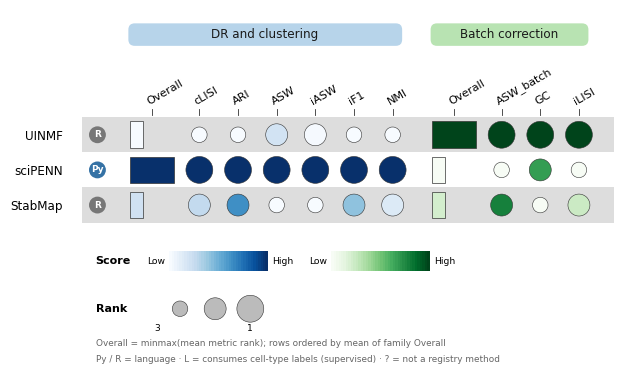

In [14]:
mine.plot()

All three reached CHAIN_OK on this subsample when we ran them. For your real data the only work is producing the
canonical files - `mtb.io.export_dataset` from an AnnData / MuData, or
`to_canonical` + `write_labels` file by file as above - and these same three
calls do the rest.

## 4. Reading stored results

Section 2 ran three methods; the package ships the **full sweep** for `D52` -
every wired method at default settings, hours of compute - so the paper's
figures reproduce from stored results in seconds. `load_results` reads them
back as the tidy frame `mtb.plot.bubble` takes, and every row says in its
`source` column which sweep it came from. The paper's table for `D52` holds 1 method against 8 in the package's sweep, so the default `source="published"` would show 1 - every call in this notebook names its source.

8 methods, ['rerun']


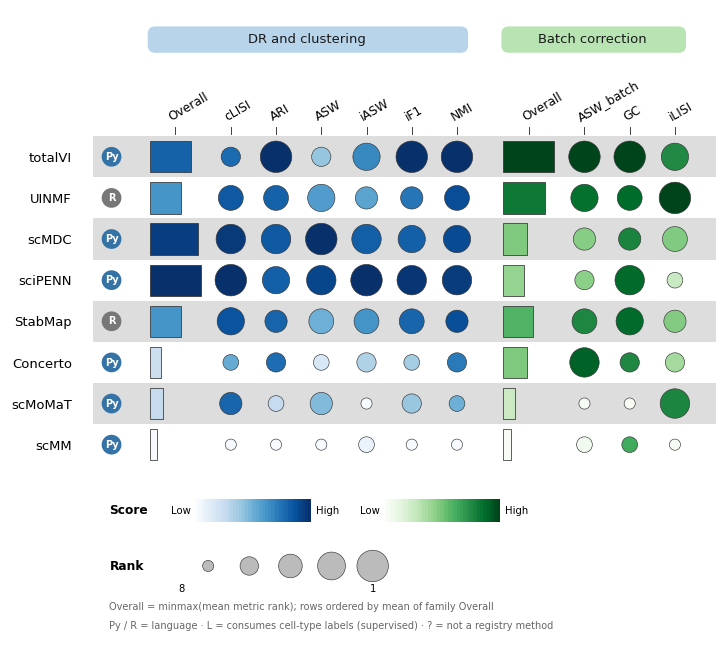

In [15]:
long = mtb.load_results(CATEGORY, dataset=DATASET, source="rerun")
print(long.method.nunique(), "methods,", long.source.unique())
fig = mtb.plot.bubble(long)
fig.set_dpi(110)
fig

`run_all(DATASET, CATEGORY, out_dir=...)` without `methods=` writes the
same `summary.csv` and `long.csv` for your own data; `mtb.load_batch(out_dir)`
reads them back. A single `mtb.evaluate` frame becomes the same seven-column
long frame with `mtb.to_long(metrics, method, dataset, category)`
(`source="user"`; `needs_labels=True` gives your own supervised method the
`L` badge), so `pd.concat([long, mine])` plots next to the stored sweep.

**Across datasets.** A summary needs every method to have results on every
dataset it averages over, or absence and performance blur into the same bar. Two
cross datasets therefore ship swept identically - `D52` and `D52s` (a 60% cell
subsample of `D52` under a new name) - and `require_complete=True` keeps only
the methods present on both, so the matrix is complete by construction. Each
bar is the **grand rank**: the min-max scaled mean rank across the datasets,
with length and colour both carrying it, and `Overall` is the same statistic
over the grand ranks. Both metric families appear because both datasets are multi-batch.

{'D52': 8, 'D52s': 8}


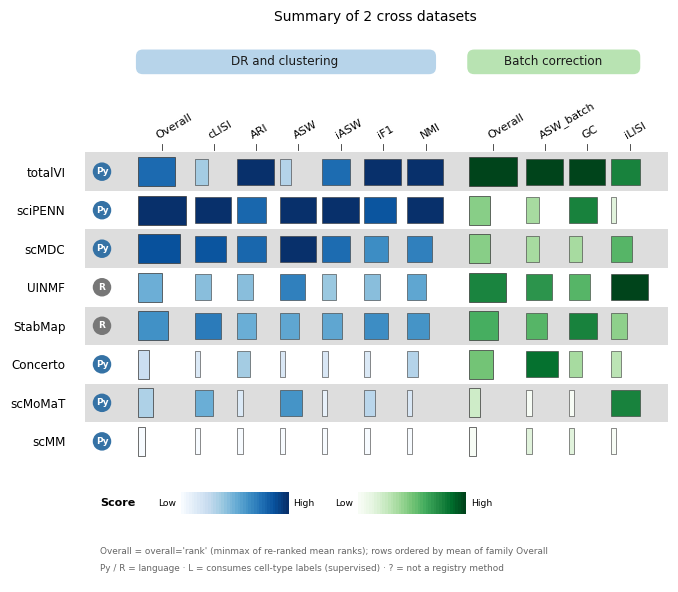

In [16]:
pair = mtb.load_results(CATEGORY, dataset=[DATASET, DATASET + "s"], source="rerun")
print(pair.groupby("dataset").method.nunique().to_dict())
mtb.plot.bubble(pair, aggregate="summary", require_complete=True,
                title=f"Summary of 2 cross datasets")

**Published vs re-run.** The paper's own tables (`source="published"`)
and the package's re-runs can differ for a method - methods are stochastic and
the published sweep ran on other hardware - so cite the published numbers and
use the re-runs to check reproducibility; compare ranks, not decimals.
`results_coverage` says what exists for this dataset and where it came from:

In [17]:
cov = mtb.results_coverage(CATEGORY)
cov[cov.dataset == DATASET].groupby("source").method.nunique()

source
published    1
rerun        8
Name: method, dtype: int64

## 5. Reference

### What runs on a dataset, and why not

`scan` inspects a folder and reports every runnable method - and for the rest,
the exact reason (missing file, missing environment, wrong layout). Nothing
executes. From the shell, `multibench scan DATASET --category CATEGORY` prints
the compact table (method, modalities, runnable, files_ok, env_ok,
runtime_tier, reason); `--columns all` or `--format csv|tsv|json` gives every
column, and `multibench run-all ... --dry-run` prints the plan plus the exact
command line per variant whose inputs resolve - the line to paste into a
scheduler job. Below, the rows the **data** admits (`files_ok`), with the
environment gate next to them: `env_ok` is what this machine has, `env_reason`
the install line for what it lacks, and `runnable` (both gates) stays empty
until the environments exist.

In [18]:
avail = mtb.scan(DATASET, category=CATEGORY)
print(f"files_ok {int(avail.files_ok.sum())}, env_ok {int(avail.env_ok.sum())}, runnable {int(avail.runnable.sum())} of {len(avail)} method variants")
avail[avail.files_ok][["method", "modalities", "env", "env_ok", "env_reason",
                       "output_kind", "needs_labels", "runtime_tier"]]

files_ok 8, env_ok 12, runnable 8 of 12 method variants


,method,modalities,env,env_ok,env_reason,output_kind,needs_labels,runtime_tier
0,Concerto,rna1+rna2+rna3+adt1+adt2+adt3,scmb_concerto,True,,embedding,False,very_slow
1,StabMap,rna1+rna2+rna3+adt1+adt2+adt3,scmb_r,True,,embedding,False,fast
2,UINMF,rna1+rna2+adt1+adt2,scmb_r,True,,embedding,False,fast
3,scMDC,rna1+rna2+rna3+adt1+adt2+adt3,scmb_scmdc,True,,embedding,False,slow
4,scMM,rna1+rna2+rna3+adt1+adt2+adt3,scmb_scmm2,True,,embedding,False,medium
5,scMoMaT,rna1+rna2+rna3+adt1+adt2+adt3,scmb_torch,True,,graph,False,medium
6,sciPENN,rna1+rna2+rna3+adt1+adt2+adt3,env_sciPENN,True,,embedding,False,fast
7,totalVI,rna1+rna2+rna3+adt1+adt2+adt3,scmb_scvi,True,,embedding,False,slow


In [19]:
not_ok = avail[~avail.files_ok][["method", "modalities", "files_reason"]]
not_ok.head(5) if len(not_ok) else "(every method's inputs resolve on this dataset)"


,method,modalities,files_reason
8,GPSA,(data_dir),FileNotFoundError: GPSA/D52/cross: spatial registration needs >=2 .h5ad slice files; found 0 in /media/disk2/Sichang/scmbench_pkg/data/D52
9,PASTE,(data_dir),FileNotFoundError: PASTE/D52/cross: spatial registration needs >=2 .h5ad slice files; found 0 in /media/disk2/Sichang/scmbench_pkg/data/D52
10,PASTE2,(data_dir),FileNotFoundError: PASTE2/D52/cross: spatial registration needs >=2 .h5ad slice files; found 0 in /media/disk2/Sichang/scmbench_pkg/data/D52
11,SPIRAL,(data_dir),FileNotFoundError: SPIRAL/D52/cross: spatial registration needs >=2 .h5ad slice files; found 0 in /media/disk2/Sichang/scmbench_pkg/data/D52


### What each method exposes for tuning

`method_info(m)["supports"]` lists a method's variants with how many
hyperparameters each exposes on its command line; `mtb.params_for(m, CATEGORY,
modalities)` names them, `params={"Method": {"key": value}}` sets them in
`run_all` (`--param METHOD:KEY=VALUE` on the command line; `multibench params
METHOD` prints the same table for every variant). An empty `tunable` is honest: many upstream scripts hardcode their hyperparameters, and this
package never edits upstream code.

In [20]:
rows = [{"method": m, "modalities": "+".join(v["modalities"]) or "(data_dir)",
         "n_tunable": v["n_tunable"], "needs_labels": v["needs_labels"],
         "output_kind": v["output_kind"]}
        for m in sorted(mtb.list_methods(category=CATEGORY))
        for v in mtb.method_info(m)["supports"] if v["category"] == CATEGORY]
pd.DataFrame(rows).sort_values(["n_tunable", "method"], ascending=[False, True]).reset_index(drop=True)

,method,modalities,n_tunable,needs_labels,output_kind
0,SPIRAL,(data_dir),25,False,coords
1,Concerto,rna1+rna2+rna3+adt1+adt2+adt3,0,False,embedding
2,GPSA,(data_dir),0,False,coords
3,PASTE,(data_dir),0,False,coords
4,PASTE2,(data_dir),0,False,coords
5,StabMap,rna1+rna2+rna3+adt1+adt2+adt3,0,False,embedding
6,UINMF,rna1+rna2+adt1+adt2,0,False,embedding
7,scMDC,rna1+rna2+rna3+adt1+adt2+adt3,0,False,embedding
8,scMM,rna1+rna2+rna3+adt1+adt2+adt3,0,False,embedding
9,scMoMaT,rna1+rna2+rna3+adt1+adt2+adt3,0,False,graph


### What the registry knows about a method, and how to cite it

`method_info` carries the upstream reference, repository and version next to
the run metadata - `availability` says whether a public install can run it
(`'public'`, or `'benchmark-host-only'` for SPIRAL, the one method whose
script is not published), `needs_labels` is the any-variant flag (`supports[i]` has it
per variant), and `verbose=True` adds the long audit notes plus
`verification`, the recorded end-to-end run(s) behind `status='verified'`
(`{dataset, category, status, wall_s, ARI, baseline, verdict, note}`);
`mtb.cite` emits the benchmark entry plus one per method you ran.

In [21]:
info = mtb.method_info("StabMap", verbose=True)
{k: info[k] for k in ("id", "env", "availability", "needs_labels", "atac", "notes", "repo_url", "version", "reference", "verification")}

{'id': 'StabMap',
 'env': 'scmb_r',
 'availability': 'public',
 'needs_labels': False,
 'atac': 'peak',
 'notes': 'Mosaic integration by stabilised mapping onto a reference embedding using shared and unshared features; R, source()d through engine/drivers/run_stabmap.R.',
 'repo_url': 'https://github.com/MarioniLab/StabMap',
 'version': '0.1.8',
 'reference': {'doi': '10.1038/s41587-023-01766-z',
  'title': 'Stabilized mosaic single-cell data integration using unshared features',
  'authors': 'Ghazanfar S, Guibentif C, Marioni JC',
  'journal': 'Nature Biotechnology',
  'year': 2024},
 'verification': [{'dataset': 'D46',
   'category': 'mosaic',
   'status': 'CHAIN_OK',
   'wall_s': 209,
   'ARI': 0.574,
   'baseline': 0.574,
   'verdict': 'OK',
   'note': None}]}

In [22]:
print(mtb.cite(['UINMF', 'sciPENN', 'StabMap'], fmt="text"))   # fmt="bibtex" for the .bib entries

Liu C, Ding S, Kim HJ, Long S, Xiao D, Ghazanfar S, Yang P. Multitask benchmarking of single-cell multimodal omics integration methods. Nature Methods (2025). https://doi.org/10.1038/s41592-025-02856-3
Kriebel AR, Welch JD. UINMF performs mosaic integration of single-cell multi-omic datasets using nonnegative matrix factorization. Nature Communications (2022). https://doi.org/10.1038/s41467-022-28431-4
Lakkis J, Schroeder A, Su K, Lee MYY, Bashore AC, Reilly MP, Li M. A multi-use deep learning method for CITE-seq and single-cell RNA-seq data integration with cell surface protein prediction and imputation. Nature Machine Intelligence (2022). https://doi.org/10.1038/s42256-022-00545-w
Ghazanfar S, Guibentif C, Marioni JC. Stabilized mosaic single-cell data integration using unshared features. Nature Biotechnology (2024). https://doi.org/10.1038/s41587-023-01766-z


### The metrics

Two families, matching the paper's grouping. All are **higher = better**, on
[0, 1] except ARI (slightly negative at chance level).

| family | metrics | what they measure |
|---|---|---|
| clustering / bio-conservation | `ARI`, `NMI`, `ASW`, `iASW`, `iF1`, `cLISI` | does the embedding separate the annotated cell types? |
| batch correction | `ASW_batch`, `GC`, `iLISI` (+ opt-in `kBET`) | are the batches mixed within each cell type? |

Batch metrics appear only when the dataset has real batches - their absence on a
single-batch dataset is correct, not missing data. `kBET` is opt-in
(`mtb.evaluate(..., slow_metrics=True)`) because it is much slower than the rest.

### Coverage of the paper

`scan()` answers "what runs on this dataset"; this answers how many of the
methods the paper benchmarks for **cross** the package wires at all. For each
one it does not, the registry's own record is printed - the categories it
**is** wired for and the tasks (`mtb.list_tasks()` vocabulary) its variants
are registered under; no variant for this category means the paper scored it
here through a task the package does not run.

In [23]:
PAPER = {'vertical': ['totalVI', 'sciPENN', 'Concerto', 'scMSI', 'Matilda', 'MOFA2', 'Multigrate', 'UINMF', 'scMoMaT', 'Seurat_WNN', 'scMM', 'scMDC', 'moETM', 'VIMCCA', 'iPOLNG', 'MIRA', 'UnitedNet', 'scMVP'], 'diagonal': ['scBridge', 'Portal', 'SCALEX', 'VIPCCA', 'Seurat_v3', 'MultiMAP', 'Seurat_v5', 'sciCAN', 'Conos', 'iNMF', 'online_iNMF', 'scJoint', 'GLUE', 'uniPort'], 'mosaic': ['MultiVI', 'scMoMaT', 'StabMap', 'Cobolt', 'UINMF', 'Multigrate', 'SMILE', 'scMM', 'moETM', 'UnitedNet', 'totalVI', 'sciPENN'], 'cross': ['totalVI', 'scMoMaT', 'UnitedNet', 'sciPENN', 'Concerto', 'scMDC', 'StabMap', 'UINMF', 'scMM', 'MOFA2', 'Multigrate', 'PASTE', 'PASTE2', 'SPIRAL', 'GPSA']}

paper = PAPER[CATEGORY]
registry = set(mtb.list_methods())
wired = sorted(m for m in registry
               if any(v["category"] == CATEGORY for v in mtb.method_info(m)["supports"]))
missing = [m for m in paper if m not in wired]
print(f"paper benchmarks {len(paper)} methods for {CATEGORY}; this package wires {len(wired)}")
for m in missing:
    if m in registry:
        info = mtb.method_info(m)
        print(f"  {m}: wired for {', '.join(info['categories'])} only (registered tasks: {', '.join(info['tasks'])})")
    else:
        print(f"  {m}: not in the registry")
if not missing:
    print("full parity with the paper for this category")

paper benchmarks 15 methods for cross; this package wires 12
  UnitedNet: wired for vertical only (registered tasks: clustering, classification)
  MOFA2: wired for vertical only (registered tasks: clustering)
  Multigrate: wired for mosaic, vertical only (registered tasks: clustering, batch)


## Troubleshooting

| symptom | meaning | fix |
|---|---|---|
| `files_ok` False: input files not found | a required file is absent | the reason names the exact file and lists what IS in the folder |
| `env_ok` False | that method's conda env is not built | the reason carries the one-method `multibench env install ...` command |
| `... looks like cells x features` | matrix stored transposed | re-export with `mtb.io.to_canonical` / `export_dataset` |
| a method FAILs in seconds | wrong input representation or layout | read `res.failures.iloc[0]["error"]` - the full command line and stderr tail are there |
| a method TIMEOUTs | slow, not broken | raise `timeout=`; runtime tiers in `scan` are measured, not guessed |
| `label_order_confidence` low | several label files fit the cell count | check `label_order_candidates` in the record |
| batch metrics scored against the wrong batches | `batch_source="file_of_origin"` is the label-file rule | `res.rescore(batch=my_vector)` re-scores the stored outputs without re-running |

### Spatial registration

`PASTE`, `PASTE2`, `SPIRAL` and `GPSA` are cross-integration methods whose output
is **aligned spatial coordinates**, not an embedding - their status reports
`RUN_OK_NO_EMBEDDING` and clustering metrics genuinely do not apply. They take
a directory of per-slice `.h5ad` files (`.X` + `obsm['spatial']`); the SPATIAL
REGISTRATION block of `describe_layout("cross")` above is the contract, and
`scan` checks the directory for it. `PASTE`, `PASTE2` and `GPSA` are public
(GPSA through the package driver `engine/drivers/run_gpsa.py`); `SPIRAL` is
`availability="benchmark-host-only"` - its script is not published, so `scan`
reports it `benchmark-host-only: script not published` and
`mtb.find_methods(task="registration", available=True)` omits it. GPSA
additionally reads `obs['Ground_Truth']` (a region / layer label per spot)
from every slice: it drives GPSA's own PAA / LTARI / SCS scores, written to
`<out_dir>/GPSA_aligned_slices/<data_dir_name>_metrics.csv`. `mtb.run` stages
the slices as sorted, zero-padded symlinks under `<out_dir>/inputs/` and writes
`<out_dir>/slices_manifest.json` mapping each `aligned_slice_<i>` to its source
file (the scripts glob without sorting; the manifest is the authority).

## Next steps

- the other three tutorials: **vertical**, **diagonal**, **mosaic**
- the hosted interactive explorer: <https://shiny.maths.usyd.edu.au/scMultiBench/> -
  the full benchmark's rankings, browsable without installing anything
- `mtb.recommend(CATEGORY, modalities=[...])` - stored-result ranking with coverage made explicit; methods wired for the category but absent from the chosen `source` appear with `grand_score` NaN rather than vanishing
- `mtb.sweep(...)` - one method over a range of one hyperparameter